In [134]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import seaborn as sns

In [110]:
# Инициализация данных для обработки
import sqlite3

with sqlite3.connect("./data.db3") as con:
    with open('./sql/select_combinations.sql', 'rt') as f:
        sql_query = f.read()
        data = pd.read_sql(sql_query, con)

In [111]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73726 entries, 0 to 73725
Data columns (total 43 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   currency  73726 non-null  object 
 1   t1_dtime  73726 non-null  object 
 2   t1_open   73726 non-null  float64
 3   t1_high   73726 non-null  float64
 4   t1_low    73726 non-null  float64
 5   t1_close  73726 non-null  float64
 6   t1_ma5    73726 non-null  float64
 7   t1_ma10   73726 non-null  float64
 8   t2_dtime  73726 non-null  object 
 9   t2_open   73726 non-null  float64
 10  t2_high   73726 non-null  float64
 11  t2_low    73726 non-null  float64
 12  t2_close  73726 non-null  float64
 13  t2_ma5    73726 non-null  float64
 14  t2_ma10   73726 non-null  float64
 15  t3_dtime  73726 non-null  object 
 16  t3_open   73726 non-null  float64
 17  t3_high   73726 non-null  float64
 18  t3_low    73726 non-null  float64
 19  t3_close  73726 non-null  float64
 20  t3_ma5    73726 non-null  fl

In [112]:
data.head()

,currency,t1_dtime,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_dtime,t2_open,...,t5_close,t5_ma5,t5_ma10,t6_dtime,t6_open,t6_high,t6_low,t6_close,t6_ma5,t6_ma10
0,AUD,2001-02-05 12:00:00,0.5507,0.5531,0.5505,0.5516,0.551600,0.551600,2001-02-06 00:00:00,0.5519,...,0.5465,0.54908,0.549080,2001-02-08 00:00:00,0.5457,0.5464,0.5445,0.5459,0.54794,0.548550
1,AUD,2001-02-06 00:00:00,0.5519,0.5527,0.5480,0.5499,0.550750,0.550750,2001-02-06 12:00:00,0.5498,...,0.5459,0.54794,0.548550,2001-02-08 12:00:00,0.5459,0.5459,0.5415,0.5421,0.54638,0.547629
2,AUD,2001-02-06 12:00:00,0.5498,0.5512,0.5473,0.5480,0.549833,0.549833,2001-02-07 00:00:00,0.5479,...,0.5421,0.54638,0.547629,2001-02-09 00:00:00,0.5420,0.5430,0.5325,0.5368,0.54414,0.546275
3,AUD,2001-02-07 00:00:00,0.5479,0.5507,0.5470,0.5494,0.549725,0.549725,2001-02-07 12:00:00,0.5494,...,0.5368,0.54414,0.546275,2001-02-09 12:00:00,0.5368,0.5370,0.5350,0.5364,0.54154,0.545178
4,AUD,2001-02-07 12:00:00,0.5494,0.5499,0.5444,0.5465,0.549080,0.549080,2001-02-08 00:00:00,0.5457,...,0.5364,0.54154,0.545178,2001-02-10 00:00:00,0.5374,0.5377,0.5342,0.5362,0.53948,0.544280


In [74]:
# Проверка пропусков
data.isnull().sum().sum()

np.int64(0)

In [113]:
COMBINATION_LENGTH = 5
TARGET_CANDLE_PREFIX = f't{(COMBINATION_LENGTH + 1)}_'
LAST_CANDLE_PREFIX = f't{(COMBINATION_LENGTH)}_'
CLASS_LABEL_KEY = 'class'
NUMERIC_KEYS_SUFFIXES = ('open', 'high', 'low', 'close', 'ma5', 'ma10')
DATE_KEY_SUFFIX = 'dtime'
DAY_OF_WEEK_PREFIX = 'dweek'

In [114]:
# Разметка
target_candle_sizes = data[TARGET_CANDLE_PREFIX + 'high'] - data[TARGET_CANDLE_PREFIX + 'low']
target_candle_body_sizes = np.abs(data[TARGET_CANDLE_PREFIX + 'open'] - data[TARGET_CANDLE_PREFIX + 'close'])

buy_class = ((data[TARGET_CANDLE_PREFIX + 'close'] > data[TARGET_CANDLE_PREFIX + 'open']) & 
             (data[TARGET_CANDLE_PREFIX + 'close'] > data[LAST_CANDLE_PREFIX + 'high']) & 
             (target_candle_body_sizes / target_candle_sizes > 0.5))

sell_class = ((data[TARGET_CANDLE_PREFIX + 'close'] < data[TARGET_CANDLE_PREFIX + 'open']) & 
              (data[TARGET_CANDLE_PREFIX + 'close'] < data[LAST_CANDLE_PREFIX + 'low']) & 
              (target_candle_body_sizes / target_candle_sizes > 0.5))

data[CLASS_LABEL_KEY] = np.where(buy_class, 1, 
                                 np.where(sell_class, 2, 0))
data.value_counts(CLASS_LABEL_KEY)

class
0    51081
1    11586
2    11059
Name: count, dtype: int64

In [115]:
import mplfinance as mpf

ITEM_INDEXES= range(1, COMBINATION_LENGTH + 1 + 1) # Количество элементов в комбинации + 1 целевой + 1 для невключительной границы

# Транспонирование одного наблюдения в последовательную комбинацию
def transpose_combination(combination_data: pd.Series) -> pd.DataFrame: 
    result = pd.DataFrame(columns=NUMERIC_KEYS_SUFFIXES)
    for i in ITEM_INDEXES:
        result.loc[pd.Timestamp(combination_data.loc[f't{i}_dtime'])] = combination_data.loc[[f't{i}_{key}' for key in NUMERIC_KEYS_SUFFIXES]].values.astype(np.float32)
    return result

def decode_class_label(combination_data: pd.Series) -> tuple[str, str]:
    cls = combination_data.get(CLASS_LABEL_KEY)
    if cls == 1:
        return ('BUY', 'green')
    elif cls == 2:
        return ('SELL', 'red')
    else:
        return ('PASS', 'grey')

# Визуализация комбинации
def print_combination(combination_data: pd.Series) -> None:
    transposed_combination = transpose_combination(combination_data)
    class_text, class_color = decode_class_label(combination_data)
    _, axes = mpf.plot(transposed_combination, type='candle', ylabel='', returnfig=True, title=f'Class: {class_text}')

    ax1 = axes[0]

    # Пометка целевой свечи
    ax1.scatter([COMBINATION_LENGTH], transposed_combination[-1:]['open'], color=class_color, s=100)
    
    # Графики MA до последней целевой свечи
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma5'][:-1], color='#FF9D68', label ='ma5')
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma10'][:-1], color='#FF7A92', label ='ma10')
    
    # График дней недели
    color = 'tab:blue'
    ax2 = ax1.twinx()
    ax2.set_ylabel('Days of week', color=color)
    ax2.plot(transposed_combination.index.day_of_week + 1, marker='o', ls='None', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(0.8, 6.2)
    ax2.grid(False)

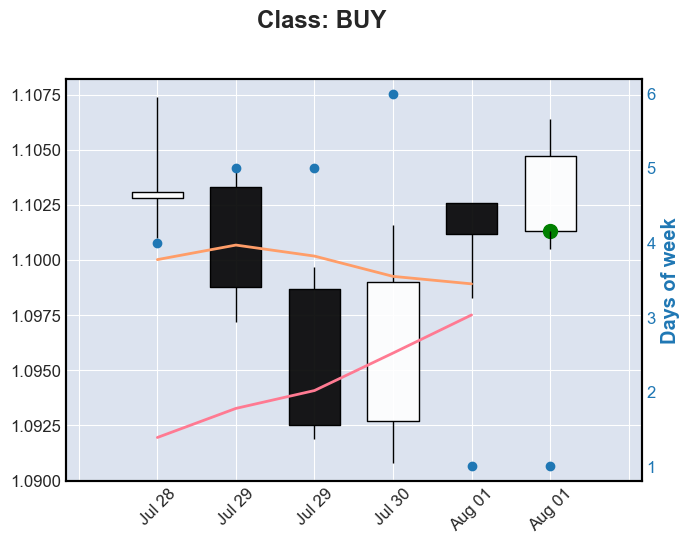

In [118]:
# Печать случайной комбинации
print_combination(data.iloc[np.random.choice(len(data))])

In [119]:
# Предобработка
from datetime import datetime

numeric_columns = [key for key in data.columns if any([key.endswith(suffix) for suffix in NUMERIC_KEYS_SUFFIXES]) and not key.startswith(TARGET_CANDLE_PREFIX)]

# Приведение ценовых показаетелей комбинации в масштаб [0,1]
data_min = data[numeric_columns].min(axis=1)
data_max = data[numeric_columns].max(axis=1)

processed_data = data.copy()
processed_data[numeric_columns] = processed_data[numeric_columns].sub(data_min, axis='rows').divide(data_max - data_min, axis='rows')

# Выделение дня недели
dtime_columns_fields = [(key, key.removesuffix(DATE_KEY_SUFFIX)) for key in data.columns if key.endswith(DATE_KEY_SUFFIX)]
for dtime_key, prefix in dtime_columns_fields:
    processed_data[prefix + DAY_OF_WEEK_PREFIX] = processed_data[dtime_key].map(lambda t: datetime.fromisoformat(t).weekday())

In [ ]:
# Удаление лишних столбцов
dtime_columns = [column[0] for column in dtime_columns_fields]
target_candle_columns = [column for column in processed_data.columns if column.startswith(TARGET_CANDLE_PREFIX)]
droped_columns = ['currency'] + dtime_columns + target_candle_columns

processed_data = processed_data.drop(droped_columns, axis=1)

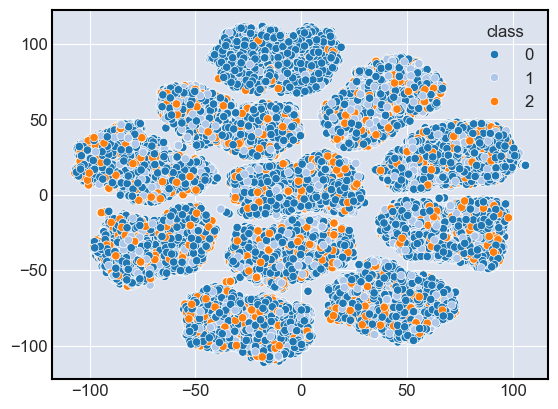

In [135]:
tsne = TSNE(n_components=2, random_state=10)
data_tsne = tsne.fit_transform(processed_data.drop([CLASS_LABEL_KEY], axis=1))

g = sns.scatterplot(x=data_tsne[:,0], y=data_tsne[:,1], palette='tab20', hue=data[CLASS_LABEL_KEY])

C:\Users\mazurenko\AppData\Local\Temp\ipykernel_12976\2827075476.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.scatterplot(x=buy_data_tsne[:,0], y=buy_data_tsne[:,1], palette='tab20')


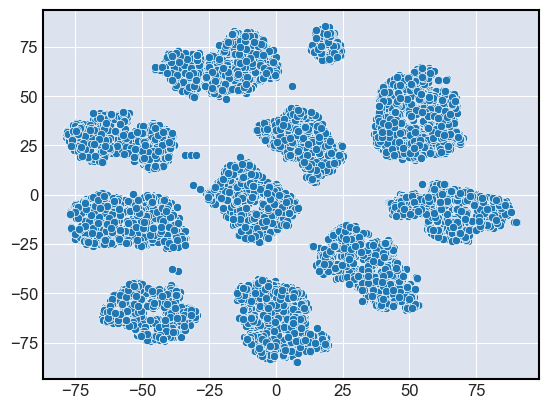

In [ ]:
tsne = TSNE(n_components=2, random_state=10)
buy_data_tsne = tsne.fit_transform(processed_data[processed_data[CLASS_LABEL_KEY] == 1])

g = sns.scatterplot(x=buy_data_tsne[:,0], y=buy_data_tsne[:,1], palette='tab20')

In [121]:
processed_data.head()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t2_open,t2_high,t2_low,t2_close,...,t5_low,t5_close,t5_ma5,t5_ma10,class,t1_dweek,t2_dweek,t3_dweek,t4_dweek,t5_dweek
0,0.724138,1.0,0.701149,0.827586,0.827586,0.827586,0.862069,0.954023,0.413793,0.632184,...,0.000000,0.241379,0.537931,0.537931,0,0,1,1,2,2
1,0.903614,1.0,0.433735,0.662651,0.765060,0.765060,0.650602,0.819277,0.349398,0.433735,...,0.012048,0.180723,0.426506,0.500000,2,1,1,2,2,3
2,0.855670,1.0,0.597938,0.670103,0.859107,0.859107,0.659794,0.948454,0.567010,0.814433,...,0.000000,0.061856,0.503093,0.631811,0,1,2,2,3,3
3,0.846154,1.0,0.796703,0.928571,0.946429,0.946429,0.928571,0.956044,0.653846,0.769231,...,0.000000,0.236264,0.639560,0.756868,0,2,2,3,3,4
4,0.971264,1.0,0.683908,0.804598,0.952874,0.952874,0.758621,0.798851,0.689655,0.770115,...,0.143678,0.224138,0.519540,0.728608,0,2,3,3,4,4


In [122]:
buy_data = data[data[CLASS_LABEL_KEY] == 1]
sell_data = data[data[CLASS_LABEL_KEY] == 2]

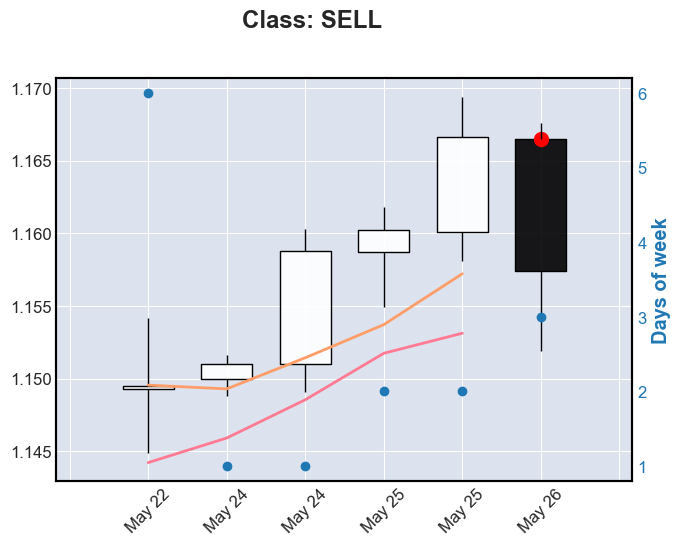

In [123]:
print_combination(sell_data.iloc[np.random.choice(len(sell_data))])

In [124]:
# Моделирование
from sklearn.metrics import precision_score
from sklearn.model_selection import train_test_split

# Разделение на множества данных
X_train, X_test, y_train, y_test = train_test_split(
    processed_data.drop([CLASS_LABEL_KEY], axis=1), processed_data[CLASS_LABEL_KEY], test_size=0.3, random_state=5, shuffle=True, stratify=processed_data[CLASS_LABEL_KEY]
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=5, stratify=y_test
)

print(f'Тренировочный набор: {y_train.value_counts()}')
print(f'Валидационный набор: {y_val.value_counts()}')
print(f'Тестовый набор: {y_test.value_counts()}')

Тренировочный набор: class
0    35757
1     8110
2     7741
Name: count, dtype: int64
Валидационный набор: class
0    7662
1    1738
2    1659
Name: count, dtype: int64
Тестовый набор: class
0    7662
1    1738
2    1659
Name: count, dtype: int64


In [136]:
from catboost import CatBoostClassifier

classifier = CatBoostClassifier(n_estimators=400, max_depth=6, learning_rate=0.1, auto_class_weights='Balanced', loss_function='MultiClass')
classifier.fit(X_train, y_train)
y_train_pred = classifier.predict(X_train)
q_train = precision_score(y_true=y_train, y_pred=y_train_pred, average=None)


print(q_train)

q_val = precision_score(y_true=y_val, y_pred=classifier.predict(X_val), average=None)
print(q_val)

# for d in depth:
#     clf = CatBoostClassifier(n_estimators=n_trees, max_depth=d, logging_level="Silent")
#     clf.fit(X_train, y_train)
#     q_train = roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1])
#     q_test = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
#     quals_cat_train.append(q_train)
#     quals_cat_test.append(q_test)

0:	learn: 1.0916864	total: 22.1ms	remaining: 8.82s
1:	learn: 1.0854599	total: 45.8ms	remaining: 9.12s
2:	learn: 1.0803750	total: 68.5ms	remaining: 9.06s
3:	learn: 1.0783318	total: 78.5ms	remaining: 7.77s
4:	learn: 1.0743143	total: 98.4ms	remaining: 7.77s
5:	learn: 1.0705609	total: 118ms	remaining: 7.73s
6:	learn: 1.0669075	total: 136ms	remaining: 7.66s
7:	learn: 1.0638088	total: 157ms	remaining: 7.7s
8:	learn: 1.0614397	total: 176ms	remaining: 7.65s
9:	learn: 1.0592479	total: 196ms	remaining: 7.66s
10:	learn: 1.0573407	total: 215ms	remaining: 7.6s
11:	learn: 1.0552764	total: 234ms	remaining: 7.58s
12:	learn: 1.0535495	total: 257ms	remaining: 7.65s
13:	learn: 1.0515060	total: 277ms	remaining: 7.64s
14:	learn: 1.0502468	total: 298ms	remaining: 7.64s
15:	learn: 1.0491422	total: 320ms	remaining: 7.67s
16:	learn: 1.0479616	total: 340ms	remaining: 7.66s
17:	learn: 1.0466661	total: 359ms	remaining: 7.62s
18:	learn: 1.0455342	total: 379ms	remaining: 7.61s
19:	learn: 1.0443924	total: 398ms	rema

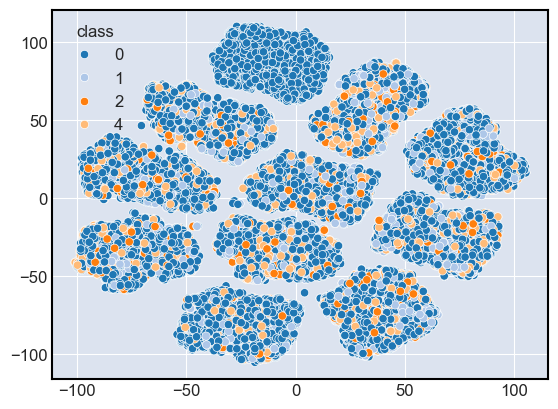

In [146]:
tsne = TSNE(n_components=2, random_state=10)
train_tsne = tsne.fit_transform(X_train)

g = sns.scatterplot(x=train_tsne[:,0], y=train_tsne[:,1], hue=y_train * y_train_pred.squeeze(), palette='tab20')